In [1]:
# -*- coding: utf-8 -*-
"""
Created on December 22, 2022
Revised on April 01, 2025

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Statsmodels Ordinary Least Squares (OLS) Vignette
==================================================

Description:
    Demonstrates simple linear regression using the statsmodels Formula API
    (ols). Generates synthetic 1D data with numpy linspace and normal noise,
    visualizes the relationship with seaborn lmplot, fits an OLS model using
    the R-style formula interface, and prints the full regression summary.

    Key statsmodels API used:
        - statsmodels.formula.api.ols(formula, data).fit()
        - RegressionResultsWrapper.summary()

References:
    1. Statsmodels Formula API ols documentation
       https://www.statsmodels.org/dev/generated/statsmodels.formula.api.ols.html

Revision History:
    2022-12-22  Original development
                - Synthetic 1D data generation with numpy linspace + normal noise
                - seaborn lmplot visualization
                - statsmodels formula API OLS fit and summary

    2025-04-01  Compatibility review and fixes for Python 3.14 / macOS M5
                - Confirmed: no np.NaN usage (clean for NumPy 2.0)
                - Fixed: seaborn lmplot updated to data-first keyword order
"""


'\nCreated on December 22, 2022\nRevised on April 01, 2025\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nStatsmodels Ordinary Least Squares (OLS) Vignette\n==================================================\n\nDescription:\n    Demonstrates simple linear regression using the statsmodels Formula API\n    (ols). Generates synthetic 1D data with numpy linspace and normal noise,\n    visualizes the relationship with seaborn lmplot, fits an OLS model using\n    the R-style formula interface, and prints the full regression summary.\n\n    Key statsmodels API used:\n        - statsmodels.formula.api.ols(formula, data).fit()\n        - RegressionResultsWrapper.summary()\n\nReferences:\n    1. Statsmodels Formula API ols documentation\n       https://www.statsmodels.org/dev/generated/statsmod

# Linear Regresion

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style("darkgrid")

# Create data

In [3]:
# Make x and y have the same space 0 to 100 and generate 50 points
x = np.linspace(0, 100, 50)

# Add randomness, notice scale refers to std dev.
y = np.linspace(0, 100, 50) + np.random.normal(scale=4, size=50)

# Build the DataFrame

In [4]:
df = pd.DataFrame({'x':x, 'y':y})

# Plot linear model

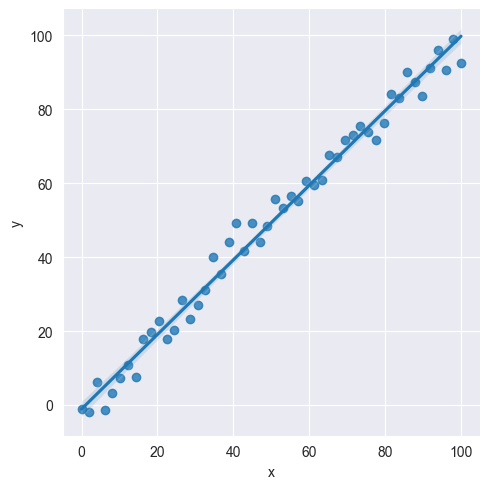

In [5]:
# seaborn lmplot: use data-first keyword order (best practice, seaborn >= 0.12)
sns.lmplot(data=df, x='x', y='y')


# Ordinary Least Squares (OLS) model

In [6]:
model = ols("y ~ x", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     3285.
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           7.32e-46
Time:                        15:16:57   Log-Likelihood:                -134.87
No. Observations:                  50   AIC:                             273.7
Df Residuals:                      48   BIC:                             277.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1134      1.021     -1.090      0.281      -3.167       0.940
x              1.0087      0.018     57.314      0.000       0.973       1.044
==============================================================================
Omnibus:                        0.106   Durbin-Watson:                   1.872
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.294
Skew:                           0.067   Prob(JB):                        0.863
Kurtosis:                       2.649   Cond. No.                         114.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""